# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

### Jan Kwinta

In [1]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import  matplotlib.pyplot as plt
from  sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# config

plt.rcParams['figure.figsize']=(8,8)
seed = 31287

In [3]:
# data

from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Colab-Notebooks/Machine-Learning/Lab-13/data/banknotes_data.csv')

Mounted at /content/drive


In [4]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [5]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [7]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [8]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [9]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

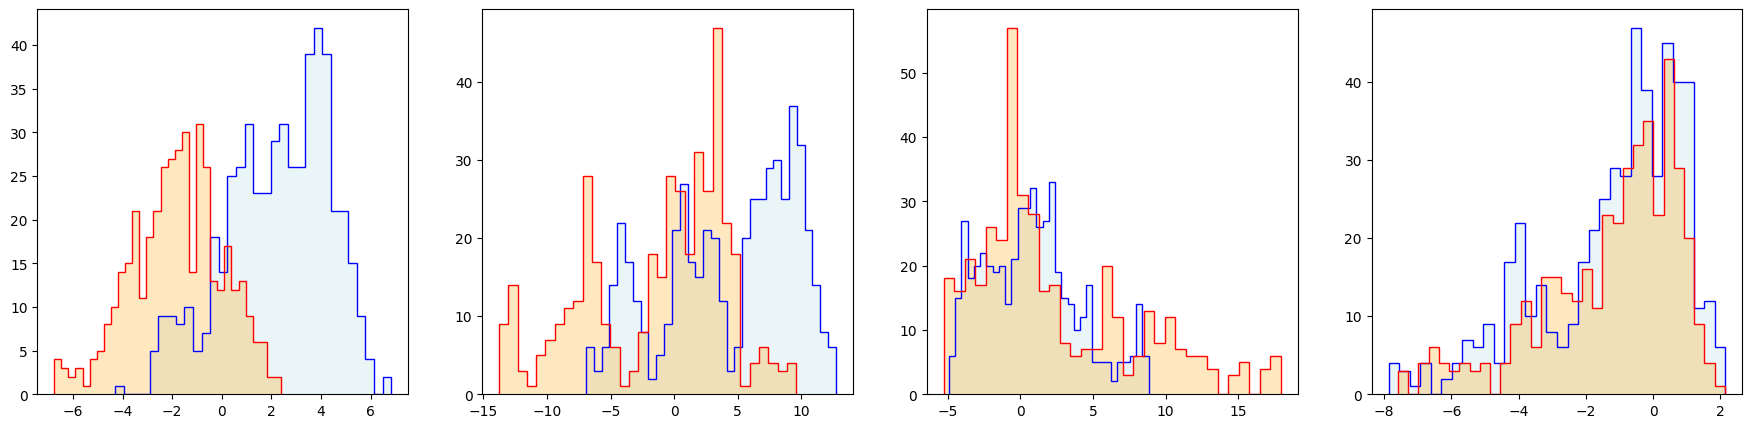

In [10]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

# Problem 1

Train a neural network classifier to predict counterfeit banknotes. Use the features `a0` and `a3`. Calculate the confussion matrix  and AUC score.

In [11]:
# data prepare

X = data[['a0', 'a3']].values
y = data['counterfeit'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

features_train = torch.FloatTensor(X_train)
labels_train = torch.FloatTensor(y_train).view(-1, 1)

features_test = torch.FloatTensor(X_test)
labels_test = torch.FloatTensor(y_test).view(-1, 1)

In [12]:
# neural network

class BanknoteNN(nn.Module):
    def __init__(self):
        super(BanknoteNN, self).__init__()
        # Zwykła sieć MLP
        self.layer1 = nn.Linear(2, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

model = BanknoteNN()
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [13]:
for era in range(50):
    for epoch in range(500):
        optimizer.zero_grad()
        pred = model(features_train)
        loss = loss_fn(pred, labels_train)
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        pred =  model(features_train)
        acc_train =  torch.mean(0.0+ ((pred > 0.5)== (labels_train>0.5)))
        pred =  model(features_test)
        acc_test =  torch.mean(0.0+ ((pred > 0.5)== (labels_test>0.5)))
    print(acc_train, acc_test)

tensor(0.9002) tensor(0.8974)
tensor(0.9174) tensor(0.9060)
tensor(0.9270) tensor(0.9103)
tensor(0.9270) tensor(0.9145)
tensor(0.9281) tensor(0.9145)
tensor(0.9227) tensor(0.8974)
tensor(0.9227) tensor(0.8974)
tensor(0.9270) tensor(0.9017)
tensor(0.9249) tensor(0.8932)
tensor(0.9270) tensor(0.9017)
tensor(0.9292) tensor(0.9060)
tensor(0.9260) tensor(0.8932)
tensor(0.9260) tensor(0.9017)
tensor(0.9303) tensor(0.9017)
tensor(0.9260) tensor(0.9017)
tensor(0.9324) tensor(0.9060)
tensor(0.9335) tensor(0.9060)
tensor(0.9249) tensor(0.9060)
tensor(0.9249) tensor(0.9017)
tensor(0.9303) tensor(0.9103)
tensor(0.9227) tensor(0.8932)
tensor(0.9238) tensor(0.9017)
tensor(0.9281) tensor(0.9017)
tensor(0.9292) tensor(0.9103)
tensor(0.9281) tensor(0.9103)
tensor(0.9217) tensor(0.9017)
tensor(0.9281) tensor(0.9060)
tensor(0.9281) tensor(0.9145)
tensor(0.9238) tensor(0.8974)
tensor(0.9260) tensor(0.8974)
tensor(0.9281) tensor(0.9103)
tensor(0.9303) tensor(0.9103)
tensor(0.9238) tensor(0.9017)
tensor(0.9

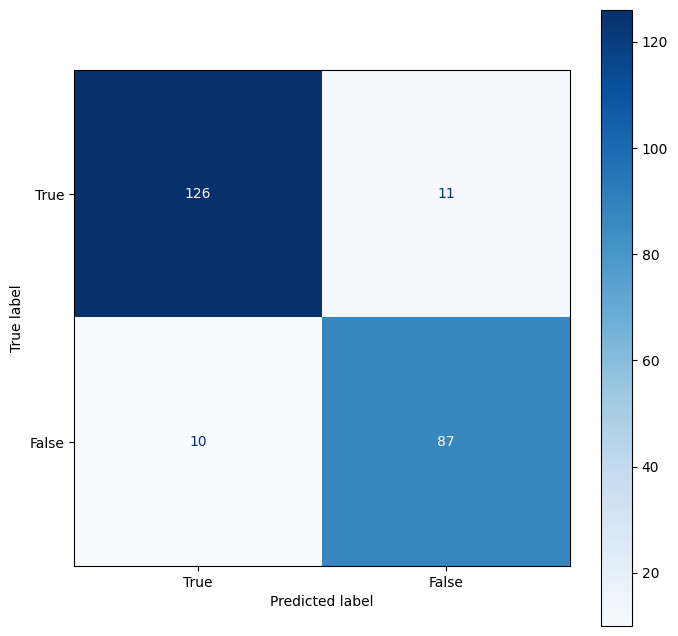

------------------

AUC score (Neural Net): 0.9621


In [14]:
# evaluation

model.eval()
with torch.no_grad():
    y_prob_tensor = model(features_test)

y_prob = y_prob_tensor.numpy()
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['True', 'False'])
disp.plot(cmap='Blues')
plt.show()

auc = roc_auc_score(y_test, y_prob)

print("------------------")
print(f'\nAUC score (Neural Net): {auc:.4f}')